In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
# Adaline Model 
# hyperparameters - eta, n_iter
# X - (examples, features)
# y - (examples,)
# w - (features,)

class Adaline_SGD:
    # ADaptive LInear NEuron classifier - Stochastic Gradient Descent
    def __init__(self, eta=0.01, n_iter = 50, random_state=1, shuffle=True):
        self.eta = eta
        self.n_iter = n_iter
        self.shuffle = shuffle
        self.random_state = random_state
        self.w_init = False
    

    def fit(self, X, y):
        self.loss_ = []
        self._initialize_weights(X.shape[1])
        
        for i in range(self.n_iter):
            temp_loss = []
            if self.shuffle :
                X, y = self._shuffle(X, y)
            
            for xi, yi in zip(X, y):
                temp_loss.append(self._update_weights(xi,yi))
            
            self.loss_.append(np.mean(temp_loss))


    def partial_fit(self, X, y):
        if not self.w_init:
            self._initialize_weights(X.shape[1])
        
        if y.ravel().shape[0] > 1:
            for xi, yi in zip(X, y):
                self._update_weights(xi, yi)
        else:
            self._update_weights(X, y)


    def _shuffle(self, X, y):
        r = self.rgen.permutation(len(y))
        return X[r], y[r]


    def _update_weights(self, X, y):
        z = self.activation(self.net_input(X))
        delta = (y-z)
        
        self.w_ += self.eta * 2.0 * X * (delta)
        self.b_ += self.eta * 2.0 * delta
        loss = delta**2
        return loss
        

    def _initialize_weights(self, len):
        self.rgen = np.random.default_rng(self.random_state)
        self.w_ = self.rgen.normal(loc=0, scale=0.3, size=len)
        self.b_ = 0.0

        self.w_init = True


    def net_input(self, X):
        # calculate net input
        return np.dot(X, self.w_) + self.b_


    def activation(self, X):
        # calculate linear activation
        # In this case an identity function
        return X


    def predict(self, X):
        # predict class label
        return np.where(self.activation(self.net_input(X))>=0.5, 1, 0)
    

In [3]:
# plotting decision regions
def plot_decision_regions(X, y, model, resolution=0.01):
    
    # color map
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    markers = ('o', 's', '^', 'v', '<')
    colmap = ListedColormap(colors[:len(np.unique(y))])

    # creating grid
    h_min, h_max = X[:,0].min()-1, X[:,0].max()+1
    v_min, v_max = X[:,1].min()-1, X[:,1].max()+1

    hh, vv = np.meshgrid(np.arange(h_min, h_max, resolution), 
                         np.arange(v_min, v_max, resolution))
    grid = np.c_[hh.ravel(), vv.ravel()] #transpose the data into required format

    # predicting class for each grid point
    grid_col = model.predict(grid)
    grid_col = grid_col.reshape(hh.shape)

    # plot decision regions
    plt.contourf(hh, vv, grid_col, alpha=0.3, cmap=colmap)
    plt.xlim(h_min, h_max)
    plt.ylim(v_min, v_max)

    # plotting sample data points over the decision regions
    for i, val in enumerate(np.unique(y)):
        plt.scatter(X[y==val, 0], X[y==val, 1], c=colors[i], marker=markers[i],
        label=f"Class {val}")

    plt.legend()

In [4]:
# Importing and formatting the data
path = '../data/iris.data'
data = pd.read_csv(path, header=None, encoding='utf-8')
print(data.head())

# setting up input and output
X = data.iloc[0:100, [0,2]].to_numpy()
# print(X[:5])

y = data.iloc[0:100, 4]
y = np.where(y=='Iris-setosa', 0, 1)
# print(y[:5])
# print(y[95:])

# feature scaling using standardization method
X_std = np.copy(X)
X_std[:,0] = (X[:,0]-X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1]-X[:,1].mean())/X[:,1].std()

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa


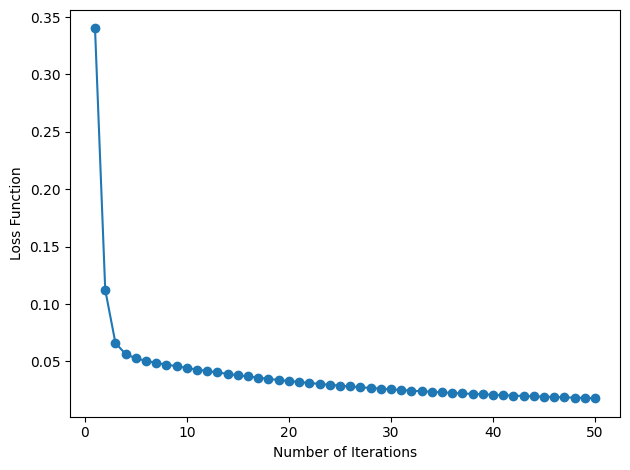

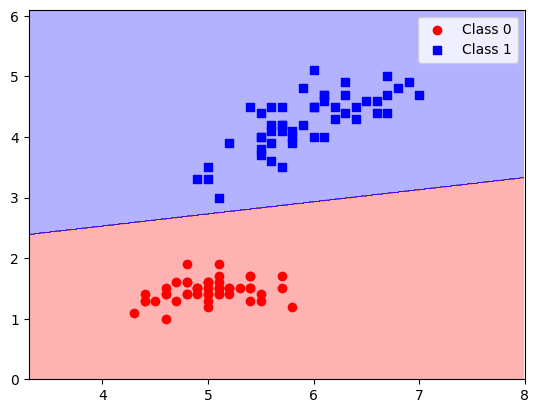

In [5]:
# Model fitting on original data
ada1 = Adaline_SGD(eta=0.0001, n_iter=50, random_state=1)
ada1.fit(X, y)

plt.plot(range(1, ada1.n_iter+1), ada1.loss_, marker='o')
plt.xlabel("Number of Iterations")
plt.ylabel("Loss Function")
plt.tight_layout()
plt.show()

plot_decision_regions(X, y, model=ada1)

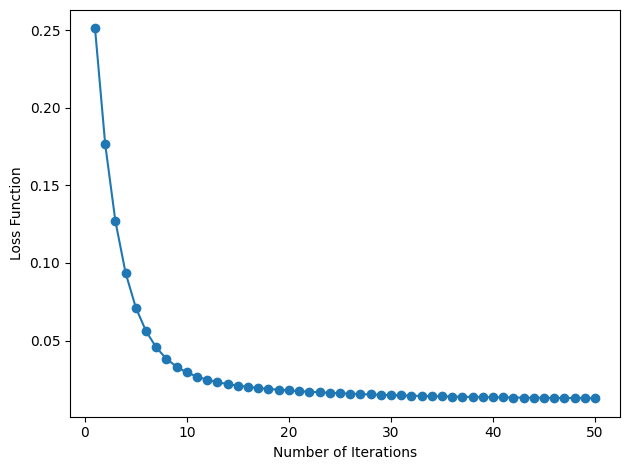

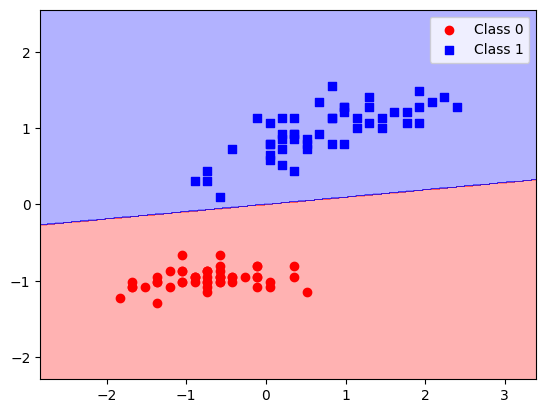

In [6]:
# Model fitting on scaled feature data
ada2 = Adaline_SGD(eta=0.001, n_iter=50, random_state=1)
ada2.fit(X_std, y)

plt.plot(range(1, ada2.n_iter+1), ada2.loss_, marker='o')
plt.xlabel("Number of Iterations")
plt.ylabel("Loss Function")
plt.tight_layout()
plt.show()

plot_decision_regions(X_std, y, model=ada2)